# PrimeMart Nigeria Ltd

## INTRODUCTION
This analysis examines the performance of PrimeMart Nigeria Ltd, a consumer goods leader, across Nigeria’s six geopolitical zones from 2023 to 2026. Utilizing a dataset of 30,000 transactions, the study evaluates how the company navigates a high volatile environment to maintain growth across all regions and product categories. This report will provide actionable insights to optimize supply chain distribution and pricing strategies within the dynamic Nigerian retail landscape.

## DATA PROCESSING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("PrimeMart_Nigeria_Sales_2023_2026.csv")
df.head()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Total_Revenue_NGN
0,PM-116835,2023-01-01,North Central,Beverages,Zobo Max 50cl,47,7735.99,363591.53
1,PM-102587,2023-01-01,South West,Beverages,Naija Cocoa Mix,44,5577.17,245395.48
2,PM-105153,2023-01-01,South East,Beverages,Naija Cocoa Mix,9,8621.51,77593.59
3,PM-105293,2023-01-01,North West,Grains & Cereals,Pride Semo,7,9506.98,66548.86
4,PM-105450,2023-01-01,South East,Beverages,Naija Cocoa Mix,8,6147.75,49182.00


In [2]:
df.tail()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Total_Revenue_NGN
29995,PM-109138,2026-04-26,South East,Grains & Cereals,Easy-Cook Beans,11,3365.08,37015.88
29996,PM-128147,2026-04-26,South West,Personal Care,Olu Herb Shampoo,7,7890.47,55233.29
29997,PM-114032,2026-04-26,South South,Grains & Cereals,Pride Semo,26,10139.96,263638.96
29998,PM-128074,2026-04-26,South South,Grains & Cereals,Pride Semo,23,9202.95,211667.85
29999,PM-124237,2026-04-26,North Central,Home Care,Bright-White Detergent,46,6400.13,294405.98


In [3]:
# Get the dimensions of the taxi_df DataFrame
# row contains the number of rows, col contains the number of columns
row, col = df.shape
# Print the dimensions of the DataFrame using an f-string
print(f"The dataset has {row} rows and {col} columns")

The dataset has 30000 rows and 8 columns


In [4]:
# Correct attribute is .dtypes (not .types)
df.dtypes

Transaction_ID        object
Date                  object
Region                object
Category              object
Product               object
Units_Sold             int64
Unit_Price_NGN       float64
Total_Revenue_NGN    float64
dtype: object

In [5]:
# Count the number of duplicate rows in the taxi_df DataFrame
# This returns the sum of True values from the duplicated() method, which identifies duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
print("---------------------------------------------------------------------------")
#identify Regions
Regions = len(df['Region'].unique())
print(f"-----There are {Regions} unique regions-----")
Region=df['Region'].unique()
print(Region)
print("---------------------------------------------------------------------------")
#Identify Category types
category=len(df['Category'].unique())
print(f"-----There are {category} unique categories-----")
Category=df['Category'].unique()
print(Category)
print("---------------------------------------------------------------------------")
#Identify product types
product=len(df['Product'].unique())
print(f"-----There are {product} unique products-----")
Product=df['Product'].unique()
print(Product)
print("---------------------------------------------------------------------------")

---------------------------------------------------------------------------
-----There are 6 unique regions-----
['North Central' 'South West' 'South East' 'North West' 'South South'
 'North East']
---------------------------------------------------------------------------
-----There are 5 unique categories-----
['Beverages' 'Grains & Cereals' 'Snacks' 'Home Care' 'Personal Care']
---------------------------------------------------------------------------
-----There are 15 unique products-----
['Zobo Max 50cl' 'Naija Cocoa Mix' 'Pride Semo' 'Kuli-Kuli Bites'
 'Germ-Kill Liquid' 'FreshMint Paste' 'Easy-Cook Beans' 'Olu Herb Shampoo'
 'Crunchy Plantain Chips' 'Chin-Chin Delight' 'Shea Glow Soap'
 'Golden Harvest Rice' 'Sparkle Dish Wash' 'Peak-Level Milk'
 'Bright-White Detergent']
---------------------------------------------------------------------------


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     30000 non-null  object 
 1   Date               30000 non-null  object 
 2   Region             30000 non-null  object 
 3   Category           30000 non-null  object 
 4   Product            30000 non-null  object 
 5   Units_Sold         30000 non-null  int64  
 6   Unit_Price_NGN     30000 non-null  float64
 7   Total_Revenue_NGN  30000 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 1.8+ MB


In [8]:
df.head()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Total_Revenue_NGN
0,PM-116835,2023-01-01,North Central,Beverages,Zobo Max 50cl,47,7735.99,363591.53
1,PM-102587,2023-01-01,South West,Beverages,Naija Cocoa Mix,44,5577.17,245395.48
2,PM-105153,2023-01-01,South East,Beverages,Naija Cocoa Mix,9,8621.51,77593.59
3,PM-105293,2023-01-01,North West,Grains & Cereals,Pride Semo,7,9506.98,66548.86
4,PM-105450,2023-01-01,South East,Beverages,Naija Cocoa Mix,8,6147.75,49182.00


In [9]:
# Rename 'Unit_Price_NGN' to 'Price_Per_Unit'
df.rename(columns={'Total_Revenue_NGN': 'Sales_NGN'}, inplace=True)

In [10]:
df.head()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Sales_NGN
0,PM-116835,2023-01-01,North Central,Beverages,Zobo Max 50cl,47,7735.99,363591.53
1,PM-102587,2023-01-01,South West,Beverages,Naija Cocoa Mix,44,5577.17,245395.48
2,PM-105153,2023-01-01,South East,Beverages,Naija Cocoa Mix,9,8621.51,77593.59
3,PM-105293,2023-01-01,North West,Grains & Cereals,Pride Semo,7,9506.98,66548.86
4,PM-105450,2023-01-01,South East,Beverages,Naija Cocoa Mix,8,6147.75,49182.00


## EXPLORATORY DATA ANALYSIS

In [11]:
Total_Rev = df['Sales_NGN'].sum()
print(f"-----Total Revenue={Total_Rev}-----")
Avg_Trans = df['Sales_NGN'].mean().round(1)
print(f"-----Average Transaction Value={Avg_Trans}-----")

-----Total Revenue=3935691371.4-----
-----Average Transaction Value=131189.7-----


In [12]:
top_region = df.groupby('Region')['Sales_NGN'].sum().sort_values(ascending=False)
print("-----Top Regions by Revenue:\n--", top_region.head(3))

-----Top Regions by Revenue:
-- Region
South West       1.357017e+09
North Central    7.998983e+08
South South      5.941155e+08
Name: Sales_NGN, dtype: float64


In [13]:
top_category = df.groupby('Category')['Sales_NGN'].sum().sort_values(ascending=False)
print("-----Top Categories by Revenue:\n--", top_category.head(3))

-----Top Categories by Revenue:
-- Category
Beverages           1.226806e+09
Grains & Cereals    1.058762e+09
Home Care           8.104115e+08
Name: Sales_NGN, dtype: float64


In [14]:
top_product = df.groupby("Product")['Sales_NGN'].sum().sort_values(ascending=False)
print("-----Top Product by Revenue:\n--",top_product.head(3))

-----Top Product by Revenue:
-- Product
Peak-Level Milk    4.132304e+08
Zobo Max 50cl      4.084438e+08
Naija Cocoa Mix    4.051320e+08
Name: Sales_NGN, dtype: float64


In [15]:
df.head()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Sales_NGN
0,PM-116835,2023-01-01,North Central,Beverages,Zobo Max 50cl,47,7735.99,363591.53
1,PM-102587,2023-01-01,South West,Beverages,Naija Cocoa Mix,44,5577.17,245395.48
2,PM-105153,2023-01-01,South East,Beverages,Naija Cocoa Mix,9,8621.51,77593.59
3,PM-105293,2023-01-01,North West,Grains & Cereals,Pride Semo,7,9506.98,66548.86
4,PM-105450,2023-01-01,South East,Beverages,Naija Cocoa Mix,8,6147.75,49182.00


### VISUALIZATIONS

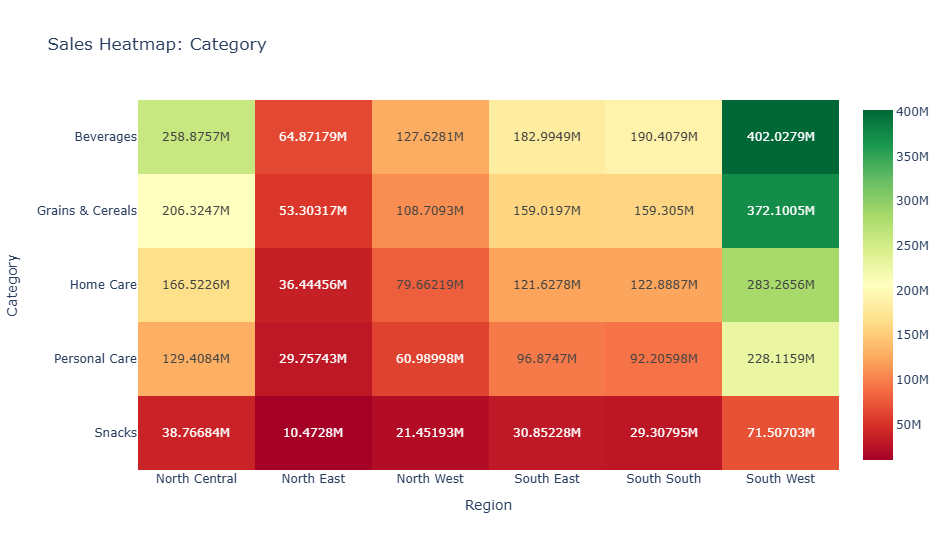

In [16]:
#Category Summary Table
pivot=df.pivot_table(values='Sales_NGN',index='Category',columns='Region', aggfunc='sum').round(0)
pivot
#Category Sales Heatmap
fig=px.imshow(pivot, text_auto=True,aspect='auto', color_continuous_scale='RdYlGn', title='Sales Heatmap: Category',height=550)
fig.show()

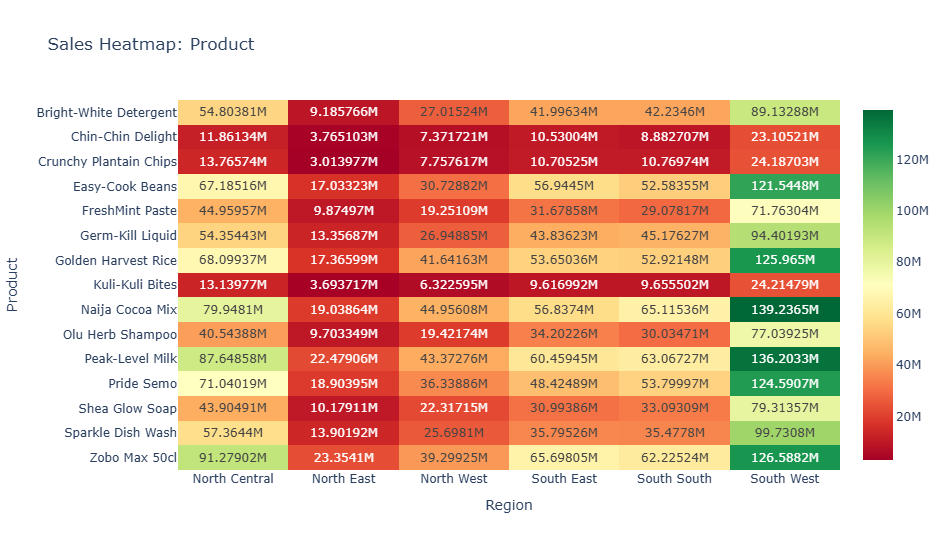

In [17]:
#Product Summary Table
pivot=df.pivot_table(values='Sales_NGN',index='Product',columns='Region', aggfunc='sum').round(0)
pivot
#Poduct Sales Heatmap
fig=px.imshow(pivot, text_auto=True,aspect='auto', color_continuous_scale='RdYlGn', title='Sales Heatmap: Product',height=550)
fig.show()

          Region         Sales  Transactions
5     South West  1.357017e+09         10400
0  North Central  7.998983e+08          6047
4    South South  5.941155e+08          4542
3     South East  5.913694e+08          4513
2     North West  3.984415e+08          3002
1     North East  1.948497e+08          1496




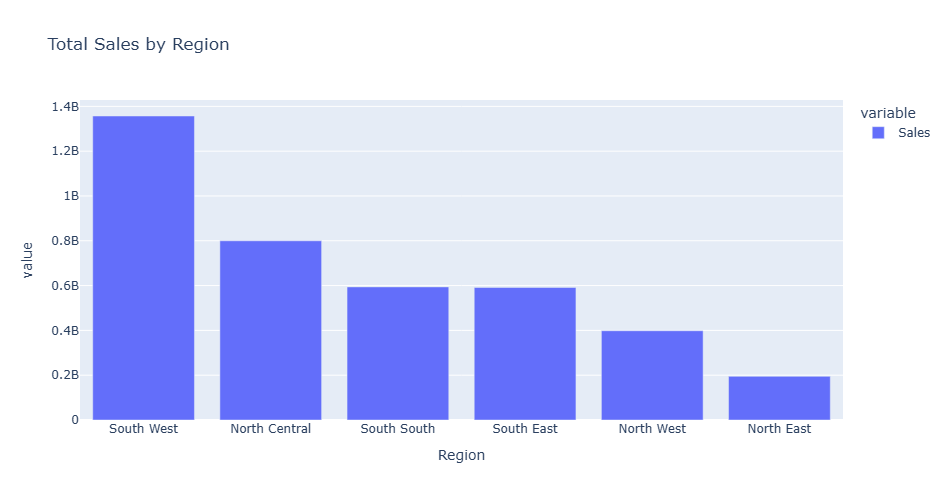

In [18]:
# Group data by Region and calculate aggregated metrics
reg_df = df.groupby("Region", as_index=False).agg(
    Sales=('Sales_NGN', 'sum'),      # Sum of all sales for each category
    Transactions=('Sales_NGN', 'count')    # Count of orders (using Sales column) for each category
).sort_values('Sales', ascending=False)  # Sort by Sales in descending order (fixed column name)

# Display the aggregated dataframe
print(reg_df)
print("\n")

# Create a grouped bar chart showing Sales and Quantity by Category
fig = px.bar(reg_df, x='Region', y=['Sales'],title='Total Sales by Region', height=500)
fig.show()

           Category         Sales  Transactions
0         Beverages  1.226806e+09          6070
1  Grains & Cereals  1.058762e+09          6043
2         Home Care  8.104115e+08          5845
3     Personal Care  6.373523e+08          5976
4            Snacks  2.023588e+08          6066




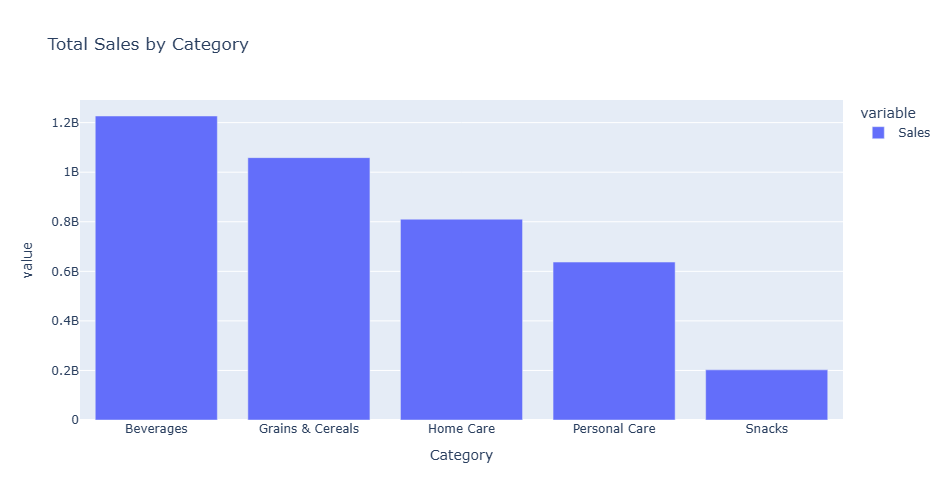

In [19]:
# Group data by Category and calculate aggregated metrics
cat_df = df.groupby("Category", as_index=False).agg(
    Sales=('Sales_NGN', 'sum'),      # Sum of all sales for each category
    Transactions=('Sales_NGN', 'count')    # Count of orders (using Sales column) for each category
).sort_values('Sales', ascending=False)  # Sort by Sales in descending order (fixed column name)

# Display the aggregated dataframe
print(cat_df)
print("\n")

# Create a grouped bar chart showing Sales and Quantity by Category
fig = px.bar(cat_df, x='Category', y=['Sales'], title='Total Sales by Category', height=500)
fig.show()

                   Product         Sales  Transactions
10         Peak-Level Milk  4.132304e+08          2039
14           Zobo Max 50cl  4.084438e+08          2006
8          Naija Cocoa Mix  4.051320e+08          2025
6      Golden Harvest Rice  3.596438e+08          2011
11              Pride Semo  3.530986e+08          2009
3          Easy-Cook Beans  3.460201e+08          2023
5         Germ-Kill Liquid  2.780746e+08          1972
13       Sparkle Dish Wash  2.679683e+08          1956
0   Bright-White Detergent  2.643686e+08          1917
12          Shea Glow Soap  2.198017e+08          2023
9         Olu Herb Shampoo  2.109452e+08          1983
4          FreshMint Paste  2.066054e+08          1970
2   Crunchy Plantain Chips  7.019935e+07          2082
7          Kuli-Kuli Bites  6.664336e+07          2010
1        Chin-Chin Delight  6.551612e+07          1974




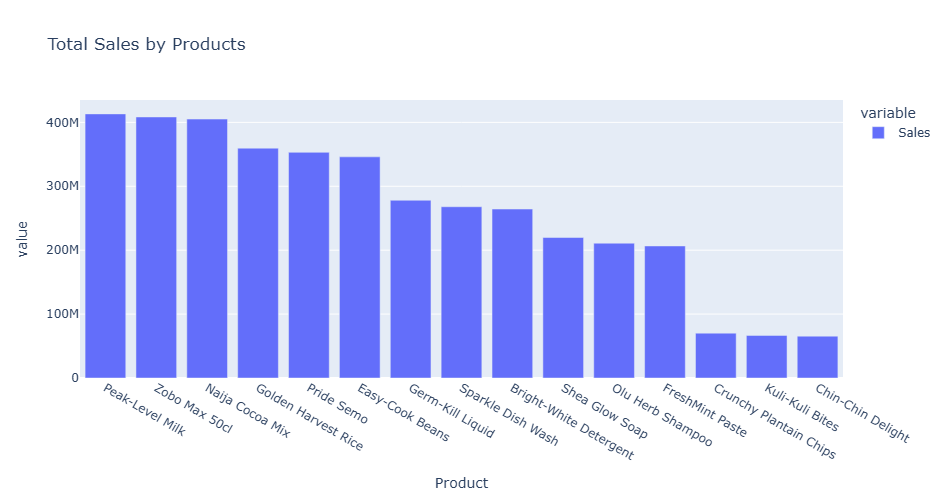

In [20]:
# Group data by Category and calculate aggregated metrics
prod_df = df.groupby("Product", as_index=False).agg(
    Sales=('Sales_NGN', 'sum'),      # Sum of all sales for each category
    Transactions=('Sales_NGN', 'count')    # Count of orders (using Sales column) for each category
).sort_values('Sales', ascending=False)  # Sort by Sales in descending order (fixed column name)

# Display the aggregated dataframe
print(prod_df)
print("\n")

# Create a grouped bar chart showing Sales and Quantity by Category
fig = px.bar(prod_df, x='Product', y=['Sales'], title='Total Sales by Products', height=500)
fig.show()

### MONTHLY SALES TREND AND SEASONALITY ANALYSIS

In [21]:
df.head()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Sales_NGN
0,PM-116835,2023-01-01,North Central,Beverages,Zobo Max 50cl,47,7735.99,363591.53
1,PM-102587,2023-01-01,South West,Beverages,Naija Cocoa Mix,44,5577.17,245395.48
2,PM-105153,2023-01-01,South East,Beverages,Naija Cocoa Mix,9,8621.51,77593.59
3,PM-105293,2023-01-01,North West,Grains & Cereals,Pride Semo,7,9506.98,66548.86
4,PM-105450,2023-01-01,South East,Beverages,Naija Cocoa Mix,8,6147.75,49182.00


In [22]:
df.dtypes

Transaction_ID     object
Date               object
Region             object
Category           object
Product            object
Units_Sold          int64
Unit_Price_NGN    float64
Sales_NGN         float64
dtype: object

In [23]:
# 1. Prepare the Data: Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Transaction_ID            object
Date              datetime64[ns]
Region                    object
Category                  object
Product                   object
Units_Sold                 int64
Unit_Price_NGN           float64
Sales_NGN                float64
dtype: object

In [24]:
df['Month_Name'] = df['Date'].dt.month_name()
df.head()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Sales_NGN,Month_Name
0,PM-116835,2023-01-01,North Central,Beverages,Zobo Max 50cl,47,7735.99,363591.53,January
1,PM-102587,2023-01-01,South West,Beverages,Naija Cocoa Mix,44,5577.17,245395.48,January
2,PM-105153,2023-01-01,South East,Beverages,Naija Cocoa Mix,9,8621.51,77593.59,January
3,PM-105293,2023-01-01,North West,Grains & Cereals,Pride Semo,7,9506.98,66548.86,January
4,PM-105450,2023-01-01,South East,Beverages,Naija Cocoa Mix,8,6147.75,49182.00,January


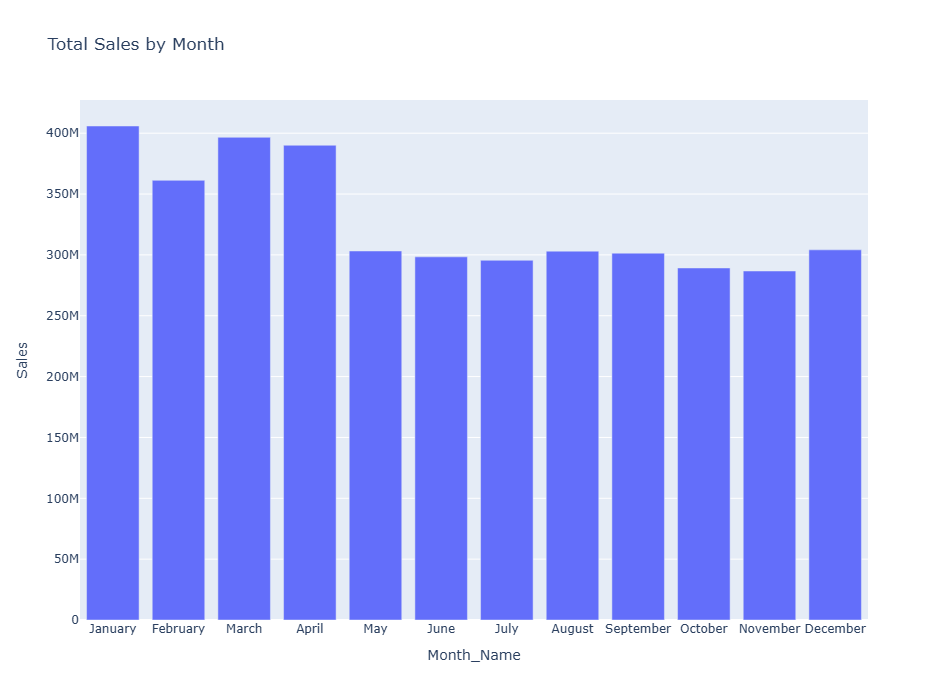

In [25]:
# 1. Define the correct chronological order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# 2. Convert 'Month_Name' to a Categorical type with this specific order
df['Month_Name'] = pd.Categorical(df['Month_Name'], categories=month_order, ordered=True)

# 3. Now, when you sort or group, it will follow the calendar!
monthly_df = df.groupby("Month_Name", as_index=False).agg(
      Sales=('Sales_NGN', 'sum'),      # Sum of all sales for each category
).sort_values("Month_Name") # This will now sort Jan -> Dec
fig = px.bar(monthly_df, x='Month_Name', y='Sales', title='Total Sales by Month', height=700)
fig.show()

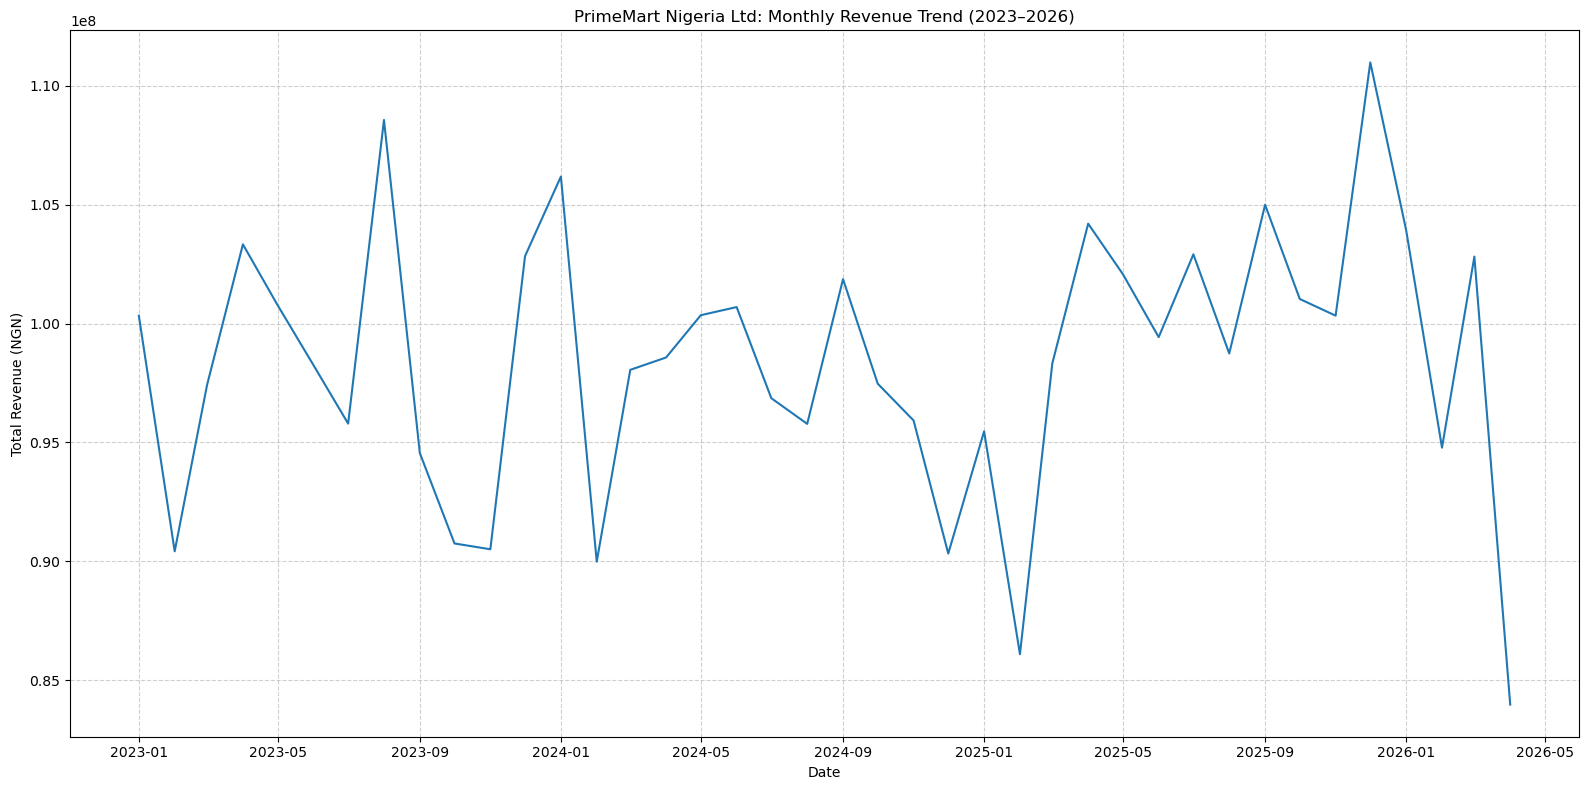

In [26]:
# 2. Resample: Aggregate Total Revenue by Month Start (MS)
monthly_trend = df.resample('MS', on='Date')['Sales_NGN'].sum().reset_index()
# 3. Visualization: Create the line graph
plt.figure(figsize=(16, 8))
plt.plot(monthly_trend['Date'], monthly_trend['Sales_NGN'])
# 4. Styling the Chart
plt.title('PrimeMart Nigeria Ltd: Monthly Revenue Trend (2023–2026)')
plt.xlabel('Date')
plt.ylabel('Total Revenue (NGN)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Correlation

In [27]:
# Calculate Pearson correlation
correlation = df['Units_Sold'].corr(df['Unit_Price_NGN'])
print(f"The correlation between Price and Units Sold is: {correlation:.2f}")

The correlation between Price and Units Sold is: -0.00


### Price Elasticity of Demand

In [28]:
# 1. Add 'Year' column for temporal comparison
df['Year'] = df['Date'].dt.year

# 2. Group by Category and Year to get average Price and Quantity
category_yearly = df.groupby(['Category', 'Year']).agg({
    'Unit_Price_NGN': 'mean',
    'Units_Sold': 'mean'
}).reset_index()

# 3. Calculate Percentage Changes within each category
category_yearly['Price_Change'] = category_yearly.groupby('Category')['Unit_Price_NGN'].pct_change()
category_yearly['Qty_Change'] = category_yearly.groupby('Category')['Units_Sold'].pct_change()

# 4. Calculate PED: (% Change in Qty) / (% Change in Price)
category_yearly['PED'] = category_yearly['Qty_Change'] / category_yearly['Price_Change']

# 5. Display the Average Elasticity by Category (ignoring the first year NaNs)
ped_summary = category_yearly.dropna().groupby('Category')['PED'].mean().reset_index()
print(ped_summary)

           Category       PED
0         Beverages -5.590476
1  Grains & Cereals  0.577186
2         Home Care  2.830036
3     Personal Care -0.848624
4            Snacks  0.763413


#### PRICE ELASTICITY ON DEMAND; BREAKDOWN:
Beverages: For every 1% increase in price, the quantity sold drops by about 5.6%. (want not need)
Grains & cereal: Panic Buying Effect (buy more because they fear prices will go even higher next week)
Home Care: price increase might have coincided with a high-demand season (like December cleaning), making it look like the price hike caused the sales spike.
Personal Care: These are "sticky" products. Even if prices go up, people still need soap and toothpaste. more "pricing power" here to offset inflation.
Snacks:

In [29]:
df.head()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Sales_NGN,Month_Name,Year
0,PM-116835,2023-01-01,North Central,Beverages,Zobo Max 50cl,47,7735.99,363591.53,January,2023
1,PM-102587,2023-01-01,South West,Beverages,Naija Cocoa Mix,44,5577.17,245395.48,January,2023
2,PM-105153,2023-01-01,South East,Beverages,Naija Cocoa Mix,9,8621.51,77593.59,January,2023
3,PM-105293,2023-01-01,North West,Grains & Cereals,Pride Semo,7,9506.98,66548.86,January,2023
4,PM-105450,2023-01-01,South East,Beverages,Naija Cocoa Mix,8,6147.75,49182.00,January,2023


In [31]:
df.tail()

,Transaction_ID,Date,Region,Category,Product,Units_Sold,Unit_Price_NGN,Sales_NGN,Month_Name,Year
29995,PM-109138,2026-04-26,South East,Grains & Cereals,Easy-Cook Beans,11,3365.08,37015.88,April,2026
29996,PM-128147,2026-04-26,South West,Personal Care,Olu Herb Shampoo,7,7890.47,55233.29,April,2026
29997,PM-114032,2026-04-26,South South,Grains & Cereals,Pride Semo,26,10139.96,263638.96,April,2026
29998,PM-128074,2026-04-26,South South,Grains & Cereals,Pride Semo,23,9202.95,211667.85,April,2026
29999,PM-124237,2026-04-26,North Central,Home Care,Bright-White Detergent,46,6400.13,294405.98,April,2026


In [30]:
df.to_csv("PrimeMartNig.csv")

## ANALYSIS

In [35]:
#Category Summary Table
pivot=df.pivot_table(values='Sales_NGN',index='Category',columns='Year', aggfunc='sum').round(0)
pivot

Year,2023,2024,2025,2026
Category,,,,
Beverages,376238395.0,365612883.0,366432167.0,118522843.0
Grains & Cereals,311877619.0,315463313.0,329366487.0,102055037.0
Home Care,247564057.0,240570901.0,244694511.0,77582027.0
Personal Care,181257054.0,189347179.0,201227549.0,65520518.0
Snacks,56589366.0,61076824.0,62877318.0,21815323.0


## CONCLUSION
### Reporting Period: January 2023 – April 2026 | Total Transactions: 30,000 | Total Revenue: ₦ ₦3,935,691,371.40

#### In order to drive 12-15% uptick in revenue this year, we recommend PrimeMart NGL, shift the business model/approach from a national franchise chain (hopes to have a presence in every geopolitical zone of the country) to a data-driven, zonal-specific growth strategy that prioritizes regional optimization and product anchoring. 
#### Rec1: We recommend defending our foundational Grains & Cereals category through minor price optimizations and "Loyalty Lock-in" programs while simultaneously reallocating marketing spend to bridge "Red" zone gaps in the North through targeted Personal Care distribution
#### Rec2: By leveraging our high-velocity "Super-SKUs" (grains & beverages) as anchors to bundle slower-moving goods (snacks) and implementing tiered volume discounts to push the Average Order Value from ₦154,000 to ₦180,000, the firm will effectively move from reactive inventory management to a predictive, high-efficiency model that captures untapped margin across the entire product periphery.